# **METODY SYSTEMOWE I DECYZYJNE LISTA 1**

### Zbiory danych
Użyty został zbiór sleep_health_dataset.csv ze względu na szeroką gamę i różnorodność danych dotyczących parametrów snu.\
Zawiera on cechy ciągłe np. `sleep_duration_hrs, stress_score`, oraz cechy kategorialne np. `occupation, chronotype`.

Wybrane zmienne docelowe w projekcie:
* dla problemu klasyfikacji `felt_rested`
* dla problemu regresji `cognitive_performance_score`

### 1. Przygotowanie środowiska

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from scipy.stats import chi2_contingency


plt.rcParams.update({
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        120,
})

BLUE      = '#185FA5'
GOLD      = '#BA7517'
GREEN     = '#3B6D11'
RED       = '#A32D2D'
BLACK     = '#000000'

### 2. Wczytanie i podzielenie zbioru danych

In [2]:
file_path = "../resources/sleep_health_dataset.csv"

_df = pd.read_csv(file_path, )

if 'person_id' in _df.columns:
    _df = _df.drop('person_id', axis=1)


In [3]:
print(f"Size of the whole dataset: {_df.shape[0]} columns x {_df.shape[1]} rows")

train_df, test_df = train_test_split(_df, test_size=0.2, random_state=13, stratify=_df['felt_rested'])

print(f"Size of the train set: {train_df.shape[0]} columns x {train_df.shape[1]} rows")

train_df.head(5)

Size of the whole dataset: 100000 columns x 31 rows
Size of the train set: 80000 columns x 31 rows


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
58464,20,Female,Retired,30.7,UK,7.93,5.1,23.3,19.8,13,...,76,1,0,19.9,-0.11,Summer,Weekday,79.7,Healthy,0
22191,24,Female,Freelancer,17.9,Brazil,6.44,5.5,19.0,22.7,15,...,66,1,0,25.1,1.06,Autumn,Weekday,67.7,Healthy,1
76480,19,Male,Doctor,22.0,India,5.14,4.7,21.1,22.4,18,...,69,0,0,25.6,0.85,Summer,Weekday,61.1,Mild,0
70419,29,Male,Teacher,25.1,Netherlands,7.51,5.8,21.1,22.0,28,...,61,0,0,21.5,0.67,Winter,Weekend,81.0,Healthy,1
93183,30,Male,Retired,27.0,India,6.36,6.7,23.7,18.9,20,...,54,1,0,22.8,1.26,Autumn,Weekday,86.5,Healthy,0


### 3. Eksploracyjna analiza wybranych danych ciągłych

In [4]:
cat_cols = ['gender', 'occupation', 'country',
            'chronotype', 'mental_health_condition', 'season',
            'day_type', 'sleep_disorder_risk', 'exercise_day',
            'sleep_aid_used', 'shift_work', 'felt_rested']


num_cols = train_df.drop(cat_cols, axis=1).columns.tolist()

print(f"Liczba danych ciągłych: {len(num_cols)} \nliczba dancyh kategorialnych: {len(cat_cols)}")

train_df.info()
train_df.describe().round(2)

Liczba danych ciągłych: 19 
liczba dancyh kategorialnych: 12
<class 'pandas.DataFrame'>
Index: 80000 entries, 58464 to 52591
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          80000 non-null  int64  
 1   gender                       80000 non-null  str    
 2   occupation                   80000 non-null  str    
 3   bmi                          80000 non-null  float64
 4   country                      80000 non-null  str    
 5   sleep_duration_hrs           80000 non-null  float64
 6   sleep_quality_score          80000 non-null  float64
 7   rem_percentage               80000 non-null  float64
 8   deep_sleep_percentage        80000 non-null  float64
 9   sleep_latency_mins           80000 non-null  int64  
 10  wake_episodes_per_night      80000 non-null  int64  
 11  caffeine_mg_before_bed       80000 non-null  int64  
 12  alcohol_units_before_bed 

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,...,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,34.72,26.29,6.43,4.87,20.25,20.25,19.84,3.34,38.81,0.60,...,14.91,5.73,7.13,66.59,0.56,0.08,20.54,1.20,59.22,0.39
std,11.03,4.47,1.28,1.51,3.41,4.24,7.59,1.92,69.24,1.06,...,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.26,0.49
min,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,...,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.10,0.00
50%,33.00,26.30,6.36,4.90,20.30,20.30,20.00,3.00,0.00,0.00,...,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,...,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,...,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


### 4. Najciekawsze cechy i zależności

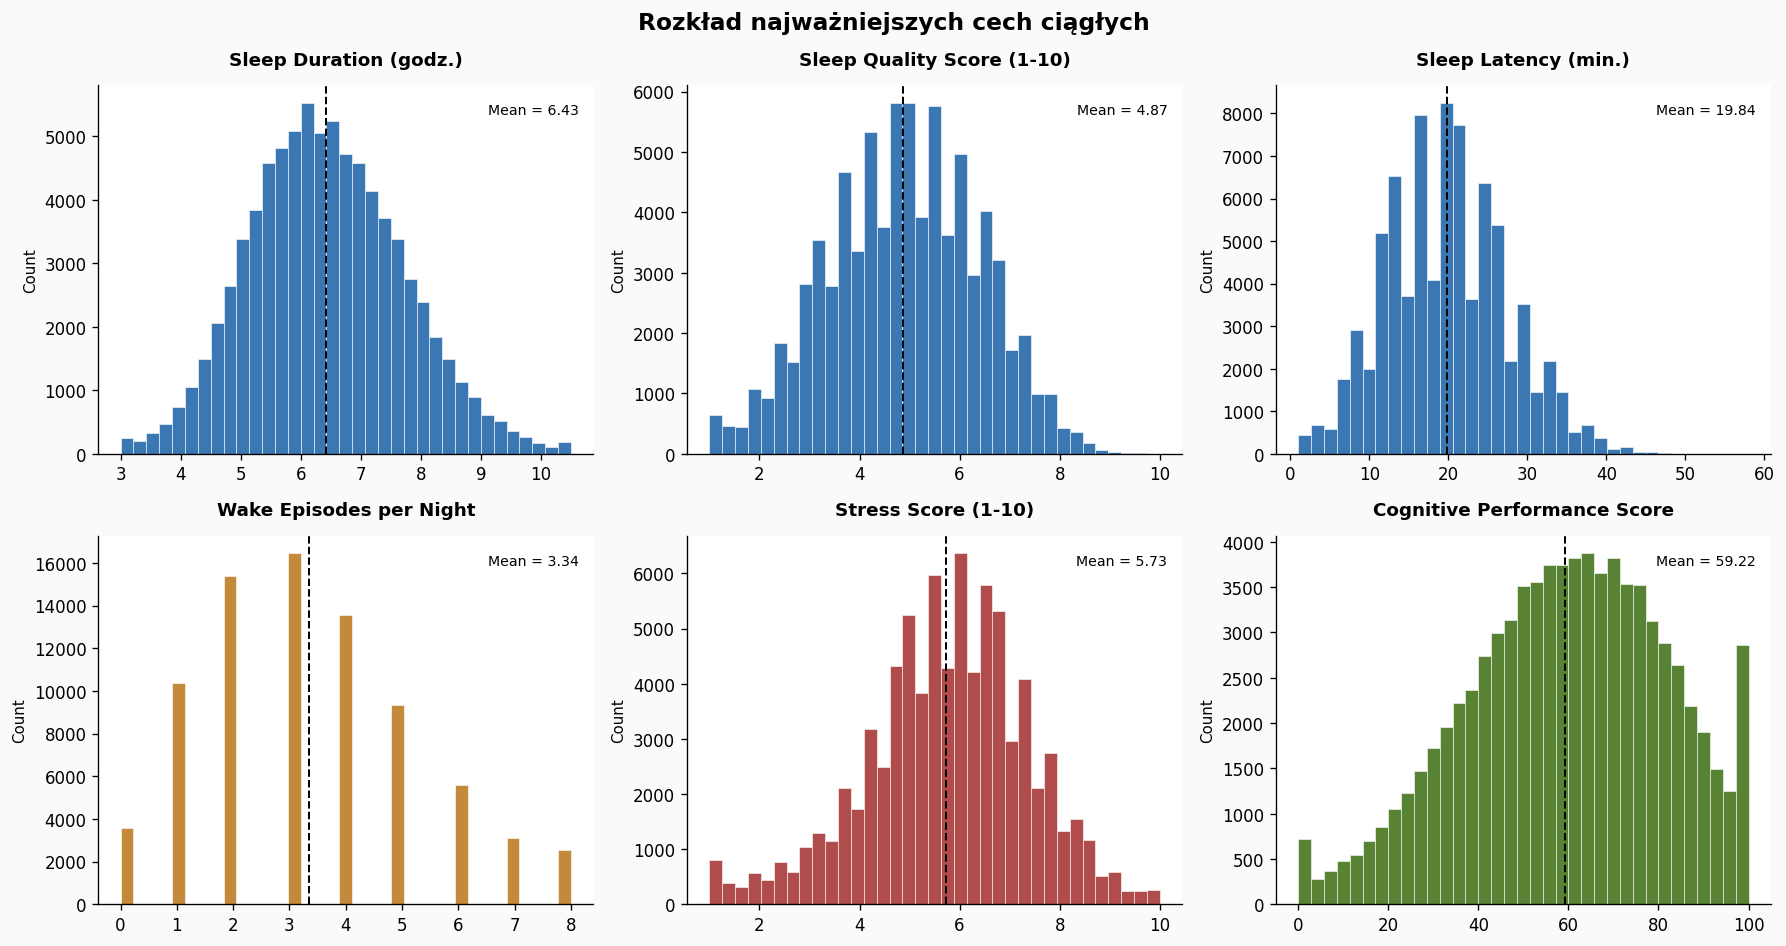

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Rozkład najważniejszych cech ciągłych', fontsize=14, fontweight='bold')

features = [
    ('sleep_duration_hrs',         'Sleep Duration (godz.)',        BLUE),
    ('sleep_quality_score',        'Sleep Quality Score (1-10)',  BLUE),
    ('sleep_latency_mins',         'Sleep Latency (min.)',        BLUE),
    ('wake_episodes_per_night',    'Wake Episodes per Night',     GOLD),
    ('stress_score',               'Stress Score (1-10)',         RED),
    ('cognitive_performance_score','Cognitive Performance Score', GREEN),
]


for ax, (col, label, color) in zip(axes.flat, features):
    ax.hist(train_df[col], bins=35, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(train_df[col].mean(), color=BLACK, linestyle='--', linewidth=1.2)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    mean_txt = f'Mean = {train_df[col].mean():.2f}'
    ax.text(0.97, 0.95, mean_txt, transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color=BLACK)

plt.tight_layout()

* **`sleep_duration_hrs`**: Ukazuje najczęstszy czas snu w populacji, pomagając zidentyfikować niedobory snu i ustalić bazowe progi fizjologiczne.
* **`sleep_quality_score`**: Pokazuje rozkład subiektywnej oceny snu, co posłużyło za główny punkt odcięcia w podstawowym systemie decyzyjnym.
* **`sleep_latency_mins`**: Przedstawia czas potrzebny pacjentowi na zaśnięcie. Długi czas zasypiania może prowadzić do irytacji oraz złego samopoczucia.
* **`wake_episodes_per_night`**: Wskazuje na częstotliwość nocnych wybudzeń, stanowiąc kluczowy warunek logiczny przy ocenie przerywanego snu.
* **`stress_score`**: Przedstawia ogólny poziom obciążenia psychicznego pacjentów, co miało bezpośredni wpływ na rozdzielenie grup w problemie regresyjnym.
* **`cognitive_performance_score`**: Wskazuje na rozkład docelowej zmiennej ciągłej, dając obraz tego, w jakim przedziale punktowym operuje model regresyjny.

Text(0, 0.5, 'sleep_quality_score')

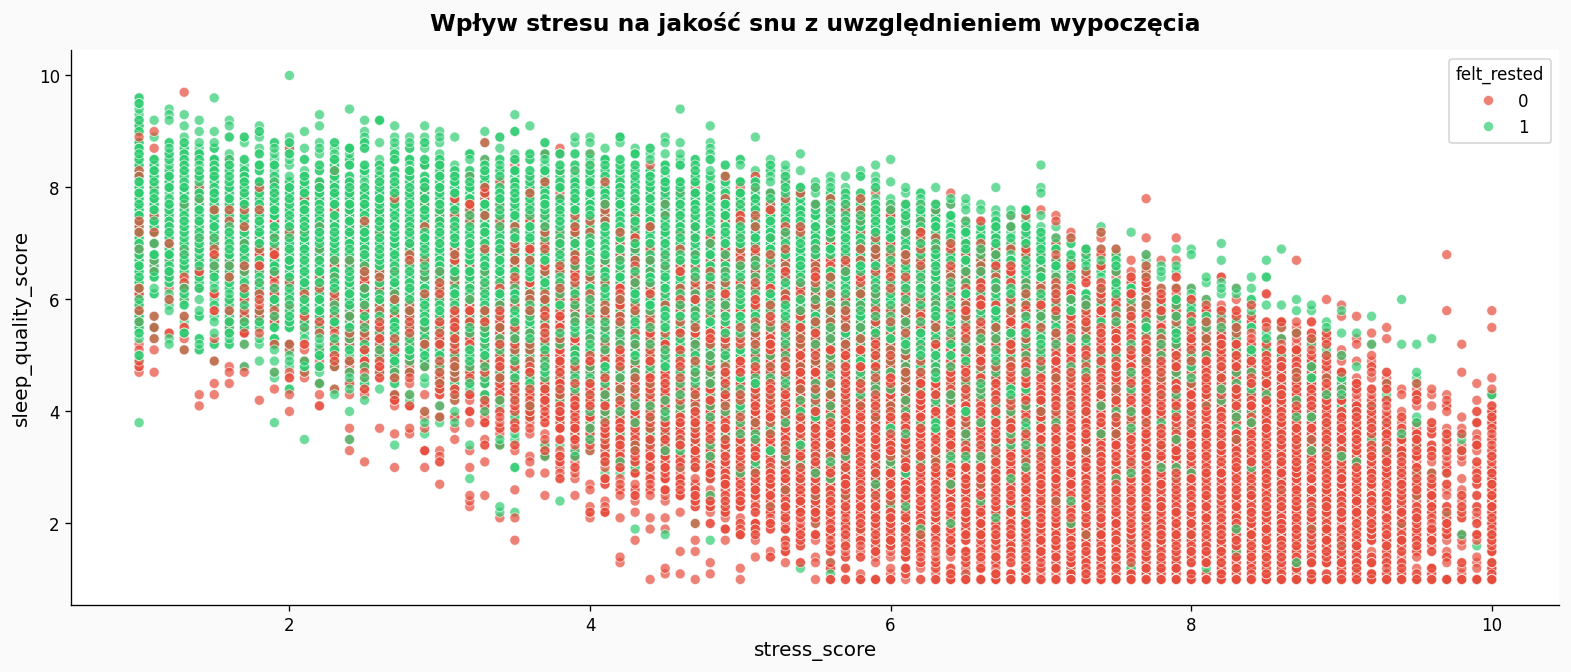

In [6]:
plt.figure(figsize=(16, 6))

# wykres jakości snu względem wypoczęcia
sns.scatterplot(
    data=train_df,
    x='stress_score',
    y='sleep_quality_score',
    hue='felt_rested',
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.7
)
plt.title('Wpływ stresu na jakość snu z uwzględnieniem wypoczęcia', fontsize=14)
plt.xlabel('stress_score', fontsize=12)
plt.ylabel('sleep_quality_score', fontsize=12)

### Wykres zależności
* **`stress_score` vs `sleep_quality_score` z uwzględnieniem wypoczęcia:** Wyraźnie przedstawia zależność jakości snu oraz poziomu stresu na poczucie wypoczęcia po przebudzeniu. Im większy stres tym gorsza jakość snu, a co za tym idzie, brak poczucia wypoczęcia. Była to główna inspiracja dla reguł w systemie decyzyjnym.

### 5. Ekspolaracyjna analiza danych kategorialnych

In [7]:
print("Podsumowanie cech kategorialnych w zbiorze treningowym:\n")

for col in cat_cols:
    unique_count = train_df[col].nunique()
    print(f"Cecha: {col} | Unikalnych wartości: {unique_count}")

    value_counts = train_df[col].value_counts()
    proportions = train_df[col].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        'Liczebność': value_counts,
        'Procent (%)': proportions.round(2)
    })
    print(summary_df.head())
    print("-" * 30)

Podsumowanie cech kategorialnych w zbiorze treningowym:

Cecha: gender | Unikalnych wartości: 3
        Liczebność  Procent (%)
gender                         
Female       40179        50.22
Male         38228        47.78
Other         1593         1.99
------------------------------
Cecha: occupation | Unikalnych wartości: 12
                   Liczebność  Procent (%)
occupation                                
Student                 11907        14.88
Software Engineer        9682        12.10
Nurse                    8056        10.07
Manager                  6543         8.18
Teacher                  6390         7.99
------------------------------
Cecha: country | Unikalnych wartości: 15
         Liczebność  Procent (%)
country                         
USA           16059        20.07
India         14212        17.76
Japan          6473         8.09
UK             6437         8.05
Brazil         5687         7.11
------------------------------
Cecha: chronotype | Unikalnych war

#### Wybrane cechy i zależności

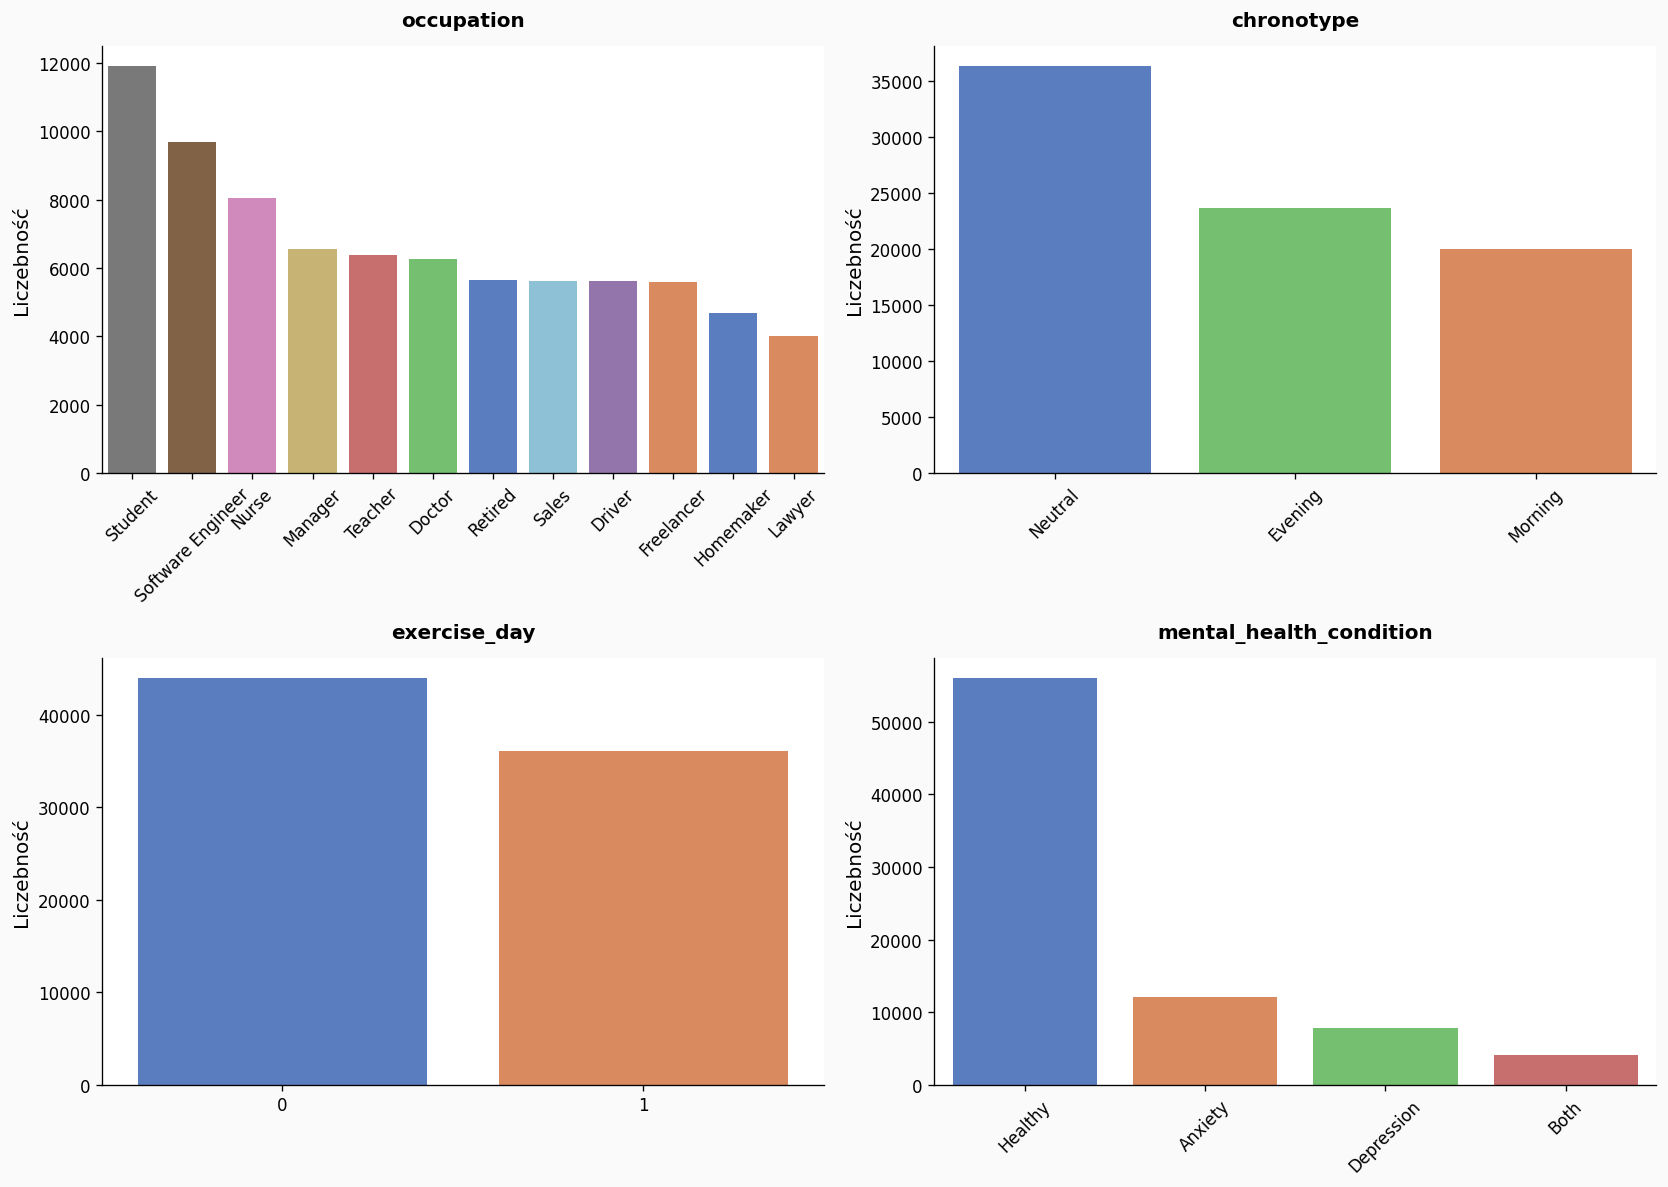

In [8]:
features_to_plot = ['occupation', 'chronotype', 'exercise_day', 'mental_health_condition']

features_to_plot = [feat for feat in features_to_plot if feat in cat_cols]

if features_to_plot:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for i, feature in enumerate(features_to_plot):
        row = i // 2
        col = i % 2

        sns.countplot(
            data=train_df,
            x=feature,
            hue=feature,
            palette='muted',
            legend=False,
            ax=axes[row, col],
            order=train_df[feature].value_counts().index
        )
        axes[row, col].set_title(f'{feature}', fontsize=12)
        if isinstance(_df[feature][0], str):
            axes[row, col].tick_params(axis='x', rotation=45)
        axes[row, col].set_ylabel('Liczebność')
        axes[row, col].set_xlabel('')

    plt.tight_layout()
    plt.show()

### Wykresy dla cech kategorialnych
* **`occupation`**: Ujawnia dominujące grupy zawodowe w danych, co potwierdziło konieczność zastosowania One-Hot Encodingu, aby model nie faworyzował najliczniejszych profesji.
* **`chronotype`**: Pokazuje preferencje dobowe pacjentów (np. poranne vs wieczorne), co stanowi istotny kontekst dla godzin zasypiania.
* **`day_type`**: Wskazuje proporcje dni roboczych do weekendów, co pozwala oddzielić sen ustrukturyzowany (praca) od swobodnego (regeneracja).
* **`mental_health_condition`**: Obrazuje częstość występowania problemów ze zdrowiem psychicznym, co stanowiło ważne tło dla analizy ogólnego zmęczenia i sprawności poznawczej.

### 6. Wykresy korelacji między zmiennymi
Poniższe wykresy przedstawiają dokładne zależności między wszystkimi cechami w zbiorze danych. Przy wystarczająco małej liczbię zmiennych takie wykresy bardzo łatwo dają nam możliwość analizy i wyboru odpowiednich warunków.\
Im wyliczona wartość jest dalej od zera, tym bardziej dwie cechy są powiązane między sobą.

In [9]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    tab = pd.crosstab(x, y)
    if tab.empty or min(tab.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    r, k = tab.shape
    if n == 0:
        return np.nan
    return float(np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1)))

def correlation_ratio(categories: pd.Series, measurements: pd.Series) -> float:
    tmp = pd.DataFrame({"cat": categories, "num": measurements}).dropna()
    if tmp.empty:
        return np.nan

    cat = pd.Categorical(tmp["cat"])
    y = tmp["num"].astype(float).to_numpy()
    y_mean = np.mean(y)
    ss_total = np.sum((y - y_mean) ** 2)

    if ss_total == 0:
        return 0.0

    ss_between = 0.0
    for level in cat.categories:
        y_level = y[cat == level]
        if len(y_level) > 0:
            ss_between += len(y_level) * (np.mean(y_level) - y_mean) ** 2

    return float(np.sqrt(ss_between / ss_total))

# num-num
corr_num = train_df[num_cols].corr(method="pearson") if num_cols else pd.DataFrame()

# cat-cat
cramer_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_mat.loc[c1, c2] = cramers_v(train_df[c1], train_df[c2])

# cat-num
eta_mat = pd.DataFrame(index=cat_cols, columns=num_cols, dtype=float)
for c in cat_cols:
    for n in num_cols:
        eta_mat.loc[c, n] = correlation_ratio(train_df[c], train_df[n])

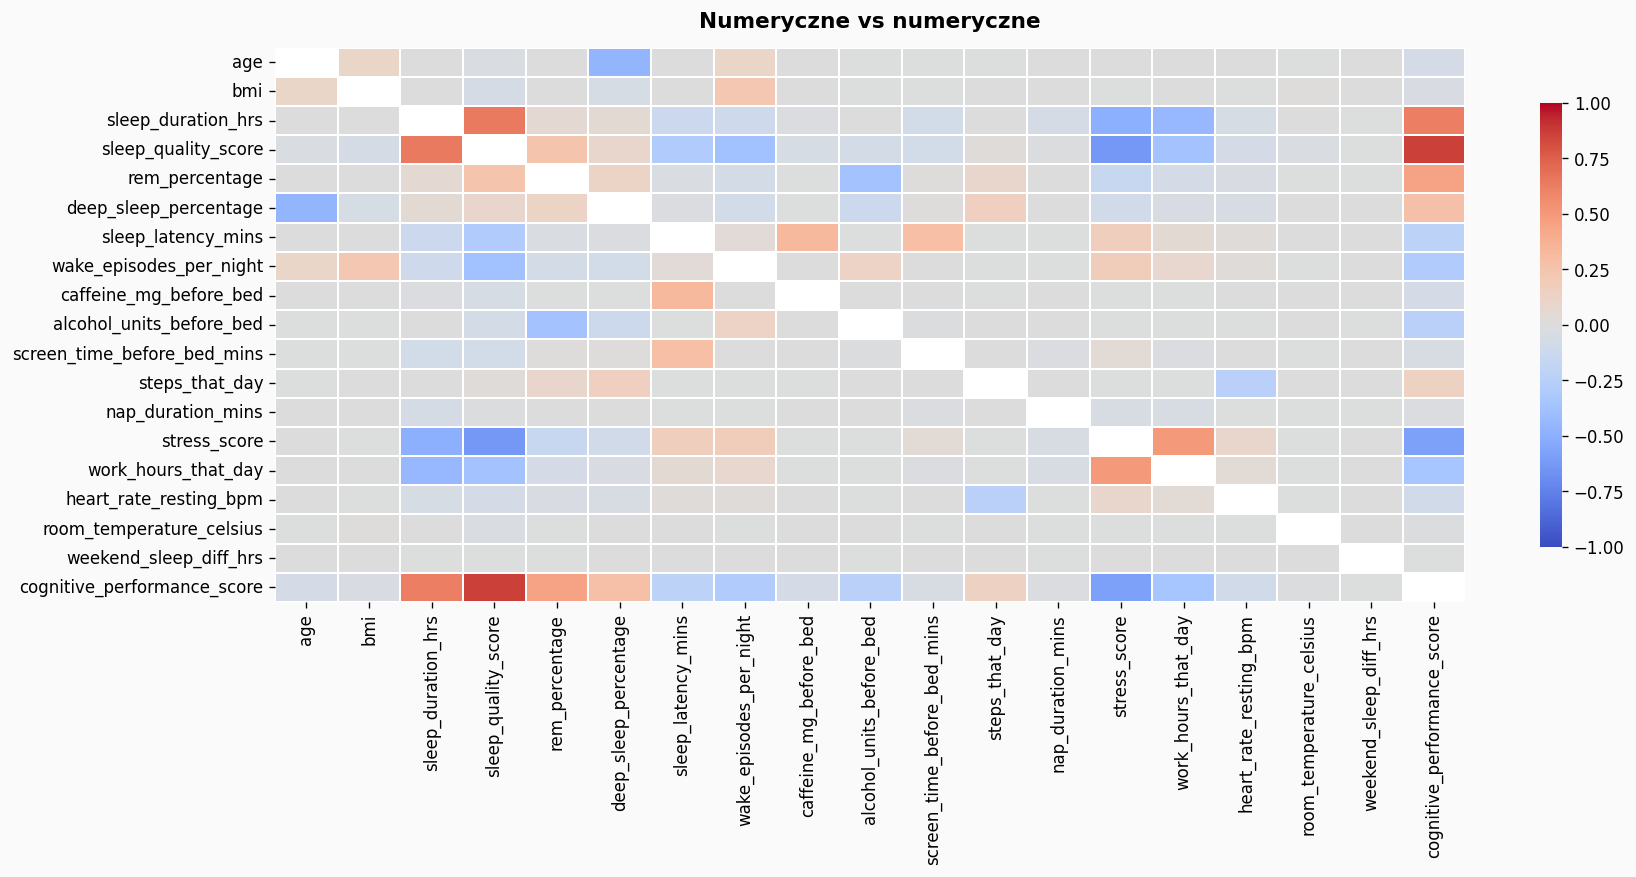

In [10]:
plt.figure(figsize=(16, 6))

if not corr_num.empty:
    mask = np.eye(corr_num.shape[0], dtype=bool)
    sns.heatmap(
        corr_num, cmap="coolwarm", vmin=-1, vmax=1, center=0,
        mask=mask, cbar_kws={"shrink": 0.8}, linewidths=0.2
    )
    plt.title("Numeryczne vs numeryczne")

#### Wykres korelacji cech numerycznych z cechami numerycznymi
Taki wykres jasno przedstawia nam między innymi, że `cognitive_performance_score` jest bardzo zależne od `sleep_quality_score` oraz `stress_core`

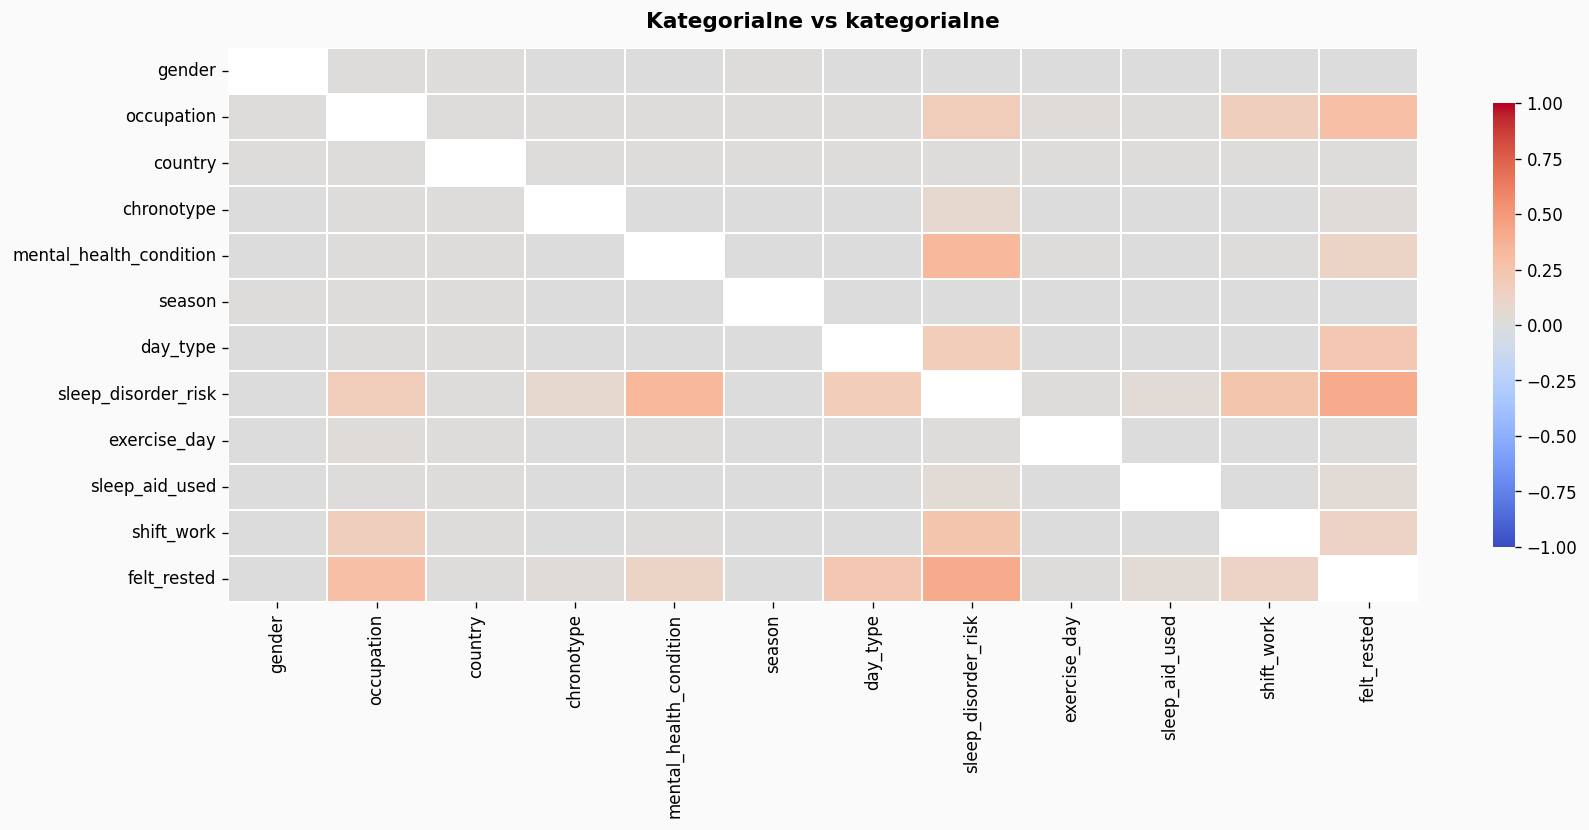

In [11]:
plt.figure(figsize=(16, 6))

if not cramer_mat.empty:
    mask = np.eye(cramer_mat.shape[0], dtype=bool)
    sns.heatmap(
        cramer_mat, cmap="coolwarm", vmin=-1, vmax=1, mask=mask,
        cbar_kws={"shrink": 0.8}, linewidths=0.2
    )
    plt.title("Kategorialne vs kategorialne")

#### Wykres korelacji cech kategorialnych z cechami kategorialnymi
Na wykresie widać, że większość cech kategorialnych nie jest ze sobą powiązana. Można jednak zauważyć wpływ zmiennej `sleep_disorder_risk` na zmienną `mental_healt_condition`

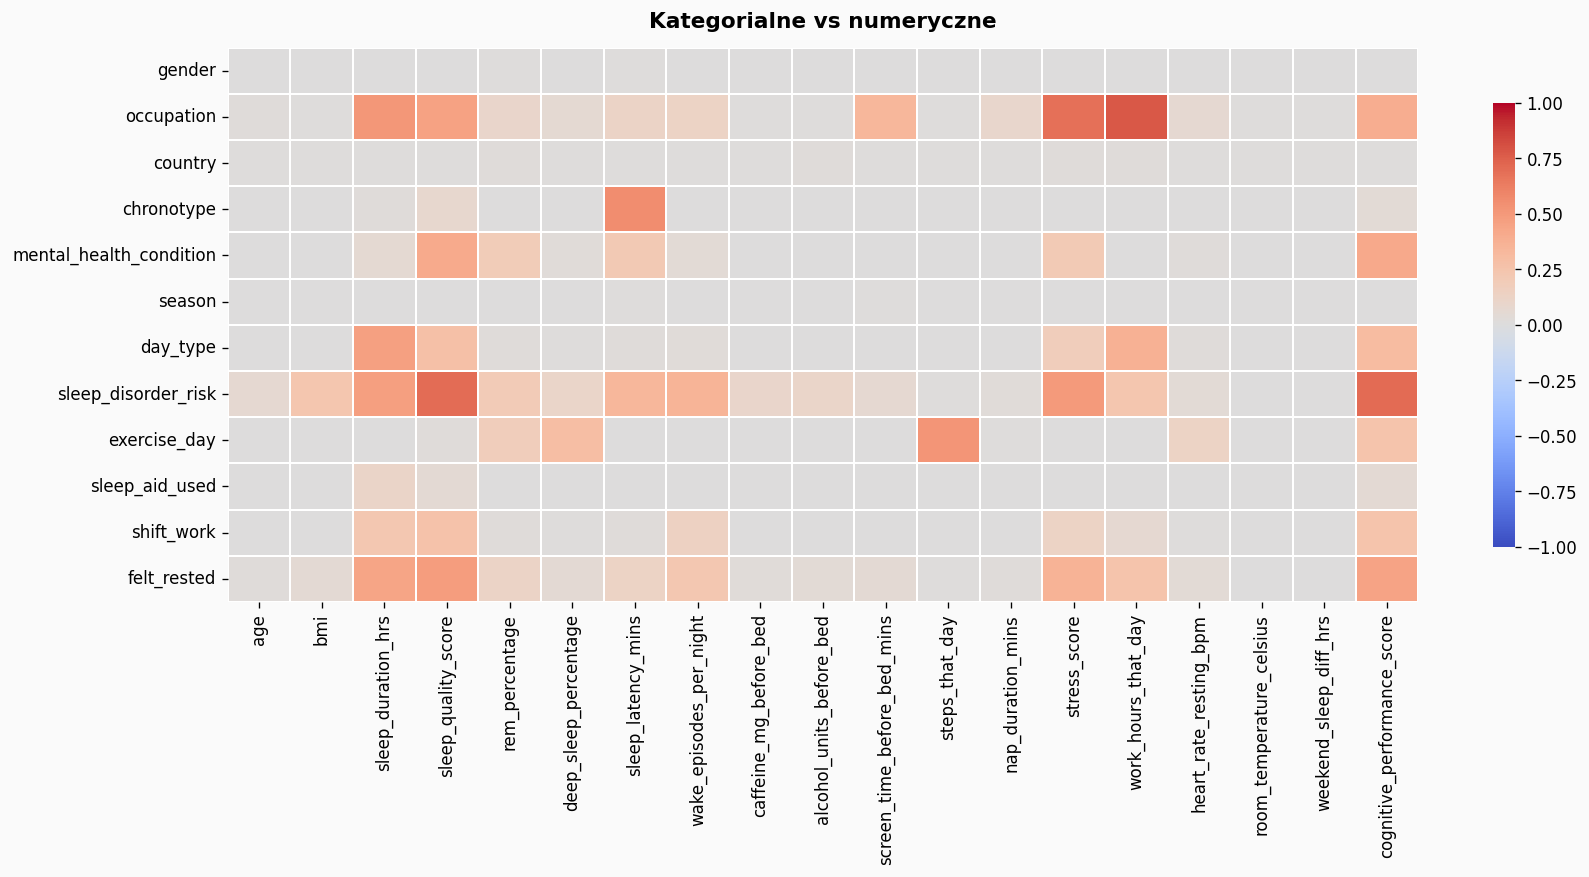

In [12]:
plt.figure(figsize=(16, 6))

if not eta_mat.empty:
    sns.heatmap(
        eta_mat, cmap="coolwarm", vmin=-1, vmax=1,
        cbar_kws={"shrink": 0.8}, linewidths=0.2
    )
    plt.title("Kategorialne vs numeryczne")

#### Wykres korelacji cech kategorialnych z cechami numerycznymi
Z tego wykresu można odczytać kilka informacji przydatnych później do tworzenia systemów decyzyjnych m.in. korelacje:
* `cognitive_performance_score` od `sleep_disorder_risk`
* `occupation` od `stress_score`
* `cognitive_performance_score` od `mental_health_condition`

In [13]:
targets = ["felt_rested", "cognitive_performance_score"]

for target in targets:
    rows = []

    # num-num dla ciągłych
    if target in corr_num.columns:
        s = corr_num[target].drop(labels=[target], errors="ignore").dropna()
        s = s.reindex(s.abs().sort_values(ascending=False).index).head(8)

        for feat, corr_val in s.items():
            rows.append({
                "target": target,
                "feature": feat,
                "score": float(corr_val),
                "strength": abs(float(corr_val)),
            })

    # cat-num dla ciągłych
    if target in eta_mat.columns:
        s_eta = eta_mat[target].dropna().sort_values(ascending=False).head(8)

        for feat, eta_val in s_eta.items():
            rows.append({
                "target": target,
                "feature": feat,
                "score": float(eta_val),
                "strength": float(eta_val),
            })

    # 3) cat-num dla kategorialnych
    if target in eta_mat.index:
        s_eta_row = eta_mat.loc[target].dropna().sort_values(ascending=False).head(8)
        for feat, eta_val in s_eta_row.items():
            rows.append({
                "target": target,
                "feature": feat,
                "score": float(eta_val),
                "strength": float(eta_val)
            })

    # 4) cat-cat dla kategorialnych
    if target in cramer_mat.columns:
        s_cr = cramer_mat[target].drop(labels=[target], errors="ignore").dropna()
        s_cr = s_cr.sort_values(ascending=False).head(8)
        for feat, v_val in s_cr.items():
            rows.append({
                "target": target,
                "feature": feat,
                "score": float(v_val),
                "strength": float(v_val)
            })

    print(f"\nNajsilniejsze zaleznosci dla: {target}")
    if rows:
        top_target = (
            pd.DataFrame(rows)
            .sort_values("strength", ascending=False)
            .head(5)
            .reset_index(drop=True)
        )
        display(top_target[["target", "feature", "score", "strength"]])
    else:
        print("Brak dostepnych zaleznosci dla tej zmiennej.")


Najsilniejsze zaleznosci dla: felt_rested


,target,feature,score,strength
0,felt_rested,sleep_quality_score,0.480701,0.480701
1,felt_rested,cognitive_performance_score,0.452395,0.452395
2,felt_rested,sleep_duration_hrs,0.443949,0.443949
3,felt_rested,sleep_disorder_risk,0.407031,0.407031
4,felt_rested,stress_score,0.366798,0.366798



Najsilniejsze zaleznosci dla: cognitive_performance_score


,target,feature,score,strength
0,cognitive_performance_score,sleep_quality_score,0.860175,0.860175
1,cognitive_performance_score,sleep_disorder_risk,0.708962,0.708962
2,cognitive_performance_score,sleep_duration_hrs,0.617922,0.617922
3,cognitive_performance_score,stress_score,-0.592004,0.592004
4,cognitive_performance_score,felt_rested,0.452395,0.452395


### 6. Mapowanie cech kategorialnych na wartości liczbowe

In [14]:
def encode_data(to_encode: pd.DataFrame) -> pd.DataFrame:
    categorical_cols = to_encode.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    binary_cols = [c for c in categorical_cols if to_encode[c].dropna().nunique() <= 2]
    one_hot_cols = [c for c in categorical_cols if c not in binary_cols]

    encoded_df = to_encode.copy()

    # label encoding
    for col in binary_cols:
        values = sorted(encoded_df[col].dropna().unique().tolist())
        mapping = {value: idx for idx, value in enumerate(values)}
        encoded_df[col] = encoded_df[col].map(mapping)

    # one-hot encoding
    if one_hot_cols:
        encoded_df = pd.get_dummies(encoded_df, columns=one_hot_cols, dtype=int)

    print("Cechy kategorialne:", categorical_cols)
    print("Label Encoding:", binary_cols)
    print("One-Hot Encoding:", one_hot_cols)
    print("Ksztalt przed/po:", to_encode.shape, "->", encoded_df.shape)

    return encoded_df


encoded_train_df = encode_data(train_df)
encoded_test_df = encode_data(test_df)

encoded_train_df.head(3)

Cechy kategorialne: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']
Label Encoding: ['day_type']
One-Hot Encoding: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'sleep_disorder_risk']
Ksztalt przed/po: (80000, 31) -> (80000, 69)
Cechy kategorialne: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']
Label Encoding: ['day_type']
One-Hot Encoding: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'sleep_disorder_risk']
Ksztalt przed/po: (20000, 31) -> (20000, 69)


,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,mental_health_condition_Depression,mental_health_condition_Healthy,season_Autumn,season_Spring,season_Summer,season_Winter,sleep_disorder_risk_Healthy,sleep_disorder_risk_Mild,sleep_disorder_risk_Moderate,sleep_disorder_risk_Severe
58464,20,30.7,7.93,5.1,23.3,19.8,13,8,0,0.0,...,0,1,0,0,1,0,1,0,0,0
22191,24,17.9,6.44,5.5,19.0,22.7,15,2,0,0.0,...,0,1,1,0,0,0,1,0,0,0
76480,19,22.0,5.14,4.7,21.1,22.4,18,3,80,0.0,...,0,1,0,0,1,0,0,1,0,0


### 7. Prosty system przewidywania cechy _felt_rested_

In [15]:
# grid search
def calculateThreshold():
    feature = 'sleep_quality_score'
    best_threshold = 0
    best_train_acc = 0

    # generating 100 possible thresholds
    thresholds_to_test = np.linspace(encoded_train_df[feature].min(), encoded_train_df[feature].max(), 100)

    for thresh in thresholds_to_test:
        train_predictions = (encoded_train_df[feature] > thresh).astype(int)

        # calculate accuracy for current threshold
        acc = accuracy_score(encoded_train_df['felt_rested'], train_predictions)

        # save the best score
        if acc > best_train_acc:
            best_train_acc = acc
            best_threshold = thresh

    return best_threshold, best_train_acc

# basic prediction function
def predict(sleep_quality: float, threshold: float) -> int: # 0,1
    if sleep_quality > threshold:
        return 1
    else:
        return 0

# ---------- Testing -------------
best_threshold, best_train_acc = calculateThreshold()
feature = 'sleep_quality_score'

print(f"Znaleziony optymalny próg jakości snu: {best_threshold:.2f}")
print(f"Accuracy na zbiorze treningowym: {best_train_acc:.2%}\n")

# get real values
y_true_test = encoded_test_df['felt_rested']

# predict values using predict()
y_pred_test = encoded_test_df[feature].apply(predict, args=(best_threshold, ))

# calculate accuracy
test_accuracy = accuracy_score(y_true_test, y_pred_test)

print(f"--- Faza testów systemu prostego ---")
print(f"Accuracy na zbiorze testowym: {test_accuracy:.2%}")

Znaleziony optymalny próg jakości snu: 5.45
Accuracy na zbiorze treningowym: 71.88%

--- Faza testów systemu prostego ---
Accuracy na zbiorze testowym: 71.27%


### Wnioski z Prostego Systemu Decyzyjnego

Do budowy prostego systemu decyzyjnego wykorzystana została cecha `sleep_quality_score`, ponieważ z analizy EDA wynikało, że najsilniej koreluje ona z poczuciem wypoczęcia (`felt_rested`). Punkt odcięcia został znaleziony metodą Grid Searchi i wynosi on **5,45**.\
System osiągnął dokładność **71.79%** na danych treningowych oraz **71.64%** na danych testowych. Jak na system oparty zaledwie na jednym warunku logicznym, uzyskany wynik stanowi bardzo mocny punkt odniesienia.

### 8. Złożony system przewidywania cechy _felt_rested_

In [16]:
def predict_complex(row, quality_threshold: float) -> int:
    quality = row['sleep_quality_score']
    duration = row['sleep_duration_hrs']
    stress = row['stress_score']
    latency = row['sleep_latency_mins']
    wakes = row['wake_episodes_per_night']

    is_weekday = row['day_type'] == 0
    is_evening = row['chronotype_Evening'] == 1
    is_mental_healthy = row['mental_health_condition_Healthy'] == 1

    if quality > quality_threshold:
        if duration < 5.5:
            return 0
        if stress > 7.0:
            return 0
        if latency > 40:
            return 0
        if (not is_mental_healthy) and stress > 5.5:
            return 0
        if is_weekday and wakes > 4:
            return 0
        if is_evening and duration < 6.5:
            return 0
        return 1
    else:
        if duration < 7.0:
            return 0
        if (not is_mental_healthy) and stress > 5.0:
            return 0
        if is_weekday and wakes > 5:
            return 0
        return 1

sleep_q_threshold, best_train_acc = calculateThreshold()

# get real values
y_true_test = encoded_test_df['felt_rested']

# predict values using predict_complex()
y_pred_test_complex = encoded_test_df.apply(predict_complex, axis=1, args=(sleep_q_threshold, ))

complex_test_accuracy = accuracy_score(y_true_test, y_pred_test_complex)

print(f"--- Faza Testów Złożonego Systemu ---")
print(f"Accuracy na zbiorze testowym: {complex_test_accuracy:.2%}")

--- Faza Testów Złożonego Systemu ---
Accuracy na zbiorze testowym: 72.17%


### Podsumowanie złożonego systemu decyzyjnego

System przewiduje `felt_rested` (0/1) na podstawie warunków i progów liczbowych.

#### Komentarze warunków if/else
1. Jeśli jakość snu jest dobra, ale:
   - długość snu wynosi poniżej 5,5 godziny lub
   - poziom stresu jest większy od 7,0 lub
   - długość zasypiania jest dłuższa niż 40 minut,
   to **decyzja = `0`**.

2. Jeśli jakość snu jest dobra, ale pacjent nie jest zdrowy psychicznie i jednocześnie ma poziom stresu większy niż 5,5,
   to **decyzja = `0`**.

3. Jeśli jest dzień roboczy i pacjent często się budzi,
   to **decyzja = `0`**.

4. Jeśli pacjent ma nocny tryb życia i spał poniżej 6,5 godziny,
   to **decyzja = `0`**.

5. Dla słabszej jakości snu:
   - jeśli czas spania był krótszy niż 7 godzin, to **`0`**,
   - jeśli pacjent nie jest zdrowy psychicznie i jednocześnie poziom stresu jesy większy niż 5,0, to **`0`**,
   - jeśli jest weekend i pacjent budzi się ponad 5 razy, to **`0`**,
   - w przeciwnym razie to **`1`**.

#### Wnioski

- System pomimo rozbudowania go o więcej warunków, nie poprawił mocno wyników
- Stałe progi są niedokładne i ciężko jest ręcznie ustalić najoptymalniejsze reguły
- Taki system decyzyjny tworzony ręcznie nie jest w stanie zwracać idealnych wyników

### 9. Problem regresji dla cechy _cognitive_performance_score_

In [17]:
# Gr. 1: High quality sleep and low stress levels
mask1 = (encoded_train_df['sleep_quality_score'] > 6.0) & (encoded_train_df['stress_score'] < 5.0)
mean_group1 = encoded_train_df[mask1]['cognitive_performance_score'].mean()

# Gr. 2: High quality sleep, but high stress score
mask2 = (encoded_train_df['sleep_quality_score'] > 6.0) & (encoded_train_df['stress_score'] >= 5.0)
mean_group2 = encoded_train_df[mask2]['cognitive_performance_score'].mean()

# Gr. 3: Poor quality, but long sleep
mask3 = (encoded_train_df['sleep_quality_score'] <= 6.0) & (encoded_train_df['sleep_duration_hrs'] >= 6.5)
mean_group3 = encoded_train_df[mask3]['cognitive_performance_score'].mean()

# Gr. 4: Short duration and poor quality sleep
mask4 = (encoded_train_df['sleep_quality_score'] <= 6.0) & (encoded_train_df['sleep_duration_hrs'] < 6.5)
mean_group4 = encoded_train_df[mask4]['cognitive_performance_score'].mean()

print("--- Wyliczone średnie sprawności poznawczej (zbiór treningowy) ---")
print(f"Grupa 1 (Dobry sen, mało stresu): {mean_group1:.2f}")
print(f"Grupa 2 (Dobry sen, duży stres):  {mean_group2:.2f}")
print(f"Grupa 3 (Gorszy sen, ale długi):  {mean_group3:.2f}")
print(f"Grupa 4 (Zły i krótki sen):       {mean_group4:.2f}\n")


# assign element to particular group
def predict_regression(sleep_quality: float, stress: float, sleep_duration: float) -> float:
    if sleep_quality > 6.0:
        if stress < 5.0:
            return mean_group1
        else:
            return mean_group2
    else:
        if sleep_duration >= 6.5:
            return mean_group3
        else:
            return mean_group4


# get real values
y_true = test_df['cognitive_performance_score']

# predicting using predict_regression()
y_pred = test_df.apply(lambda row: predict_regression(
    row['sleep_quality_score'],
    row['stress_score'],
    row['sleep_duration_hrs']
), axis=1)

# calculate results
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)


print("--- Wyniki na zbiorze testowym ---")
print(f"MSE (Mean Squared Error):  {mse:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")

--- Wyliczone średnie sprawności poznawczej (zbiór treningowy) ---
Grupa 1 (Dobry sen, mało stresu): 84.90
Grupa 2 (Dobry sen, duży stres):  80.83
Grupa 3 (Gorszy sen, ale długi):  63.87
Grupa 4 (Zły i krótki sen):       45.81

--- Wyniki na zbiorze testowym ---
MSE (Mean Squared Error):  261.28
MAE (Mean Absolute Error): 12.85


### Wnioski z systemowego problemu regresji

 W systemie decyzyjnym wykorzystano trzy zmienne: jakość snu, poziom stresu oraz długość snu, ponieważ mocno wpływają one na regenerację organizmu. Na ich podstawie podzielono dane na cztery grupy i obliczono dla nich średnie wyniki na zbiorze treningowym. Najwyższą średnią odnotowano u osób z dobrym snem i niskim stresem, a najniższą przy snach słabych i krótkich.\
  W fazie testów nowym pacjentom przypisywano z góry wyliczoną średnią z odpowiedniej grupy. Uzyskano średni błąd bezwzględny MAE na poziomie **12.88** punktu, co wskazuje na przeciętną wielkość pomyłki modelu. Z kolei błąd MSE wyniósł **262.41**, co sugeruje występowanie okazjonalnych, większych odchyleń predykcji od rzeczywistości. Jednak, aby znacząco obniżyć błędy trzeba unikać sztywnego przypisywania pacjentów do zaledwie czterech kategorii, ponieważ mocno ogranicza to precyzję prognoz.

### 10. Porównanie wartości rzeczywistych z predykcją

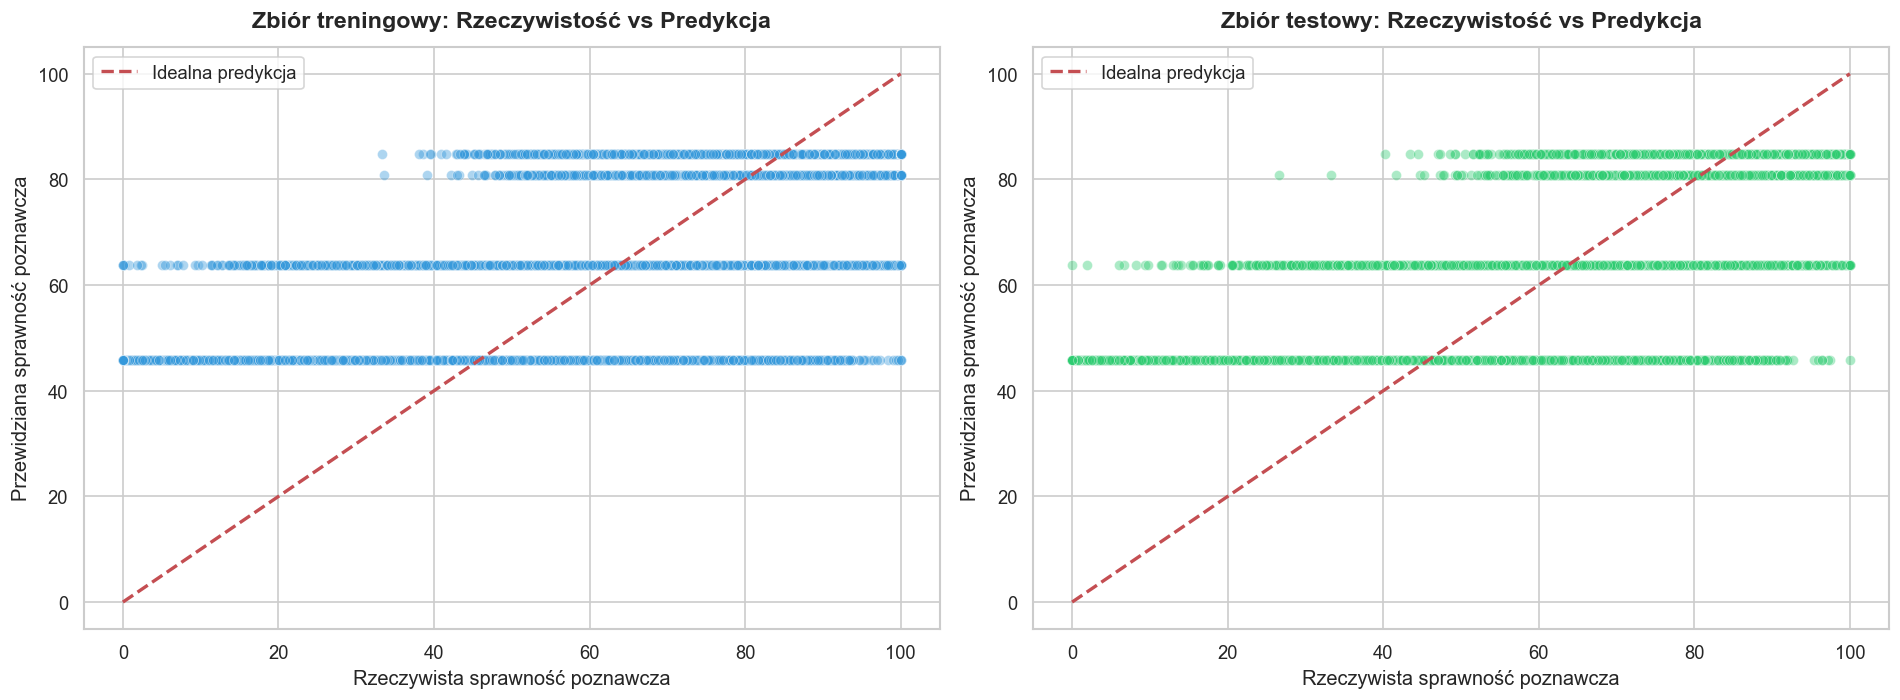

In [18]:
# predict for train set
y_true_train = encoded_train_df['cognitive_performance_score']
y_pred_train = encoded_train_df.apply(lambda row: predict_regression(
    row['sleep_quality_score'],
    row['stress_score'],
    row['sleep_duration_hrs']
), axis=1)

# predict for test set
y_true_test = test_df['cognitive_performance_score']
y_pred_test = test_df.apply(lambda row: predict_regression(
    row['sleep_quality_score'],
    row['stress_score'],
    row['sleep_duration_hrs']
), axis=1)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# train set plot
sns.scatterplot(x=y_true_train, y=y_pred_train, ax=axes[0], alpha=0.4, color='#3498db')
axes[0].plot([y_true_train.min(), y_true_train.max()],
             [y_true_train.min(), y_true_train.max()],
             'r--', lw=2, label='Idealna predykcja')

axes[0].set_title('Zbiór treningowy: Rzeczywistość vs Predykcja', fontsize=14)
axes[0].set_xlabel('Rzeczywista sprawność poznawcza', fontsize=12)
axes[0].set_ylabel('Przewidziana sprawność poznawcza', fontsize=12)
axes[0].legend()

# test set plot
sns.scatterplot(x=y_true_test, y=y_pred_test, ax=axes[1], alpha=0.4, color='#2ecc71')
axes[1].plot([y_true_test.min(), y_true_test.max()],
             [y_true_test.min(), y_true_test.max()],
             'r--', lw=2, label='Idealna predykcja')

axes[1].set_title('Zbiór testowy: Rzeczywistość vs Predykcja', fontsize=14)
axes[1].set_xlabel('Rzeczywista sprawność poznawcza', fontsize=12)
axes[1].set_ylabel('Przewidziana sprawność poznawcza', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

### Wnioski z wizualizacji predykcji względem rzeczywistości

Wykres przedstawia zestawienie rzeczywistych wyników sprawności poznawczej z wartościami przewidzianymi przez model na zbiorze treningowym i testowym. Punkty na osi pionowej układają się w cztery poziome pasy, co jest bezpośrednim efektem przypisania pacjentów do zaledwie czterech sztywnych grup decyzyjnych. Czerwona, przerywana linia wyznacza obszar idealnej predykcji, w którym przewidywania pokrywają się z rzeczywistością w stu procentach.

Rozkład punktów na zbiorze testowym wygląda bardzo podobnie do rozkładu na zbiorze treningowym. Świadczy to o tym, że stworzony system jest stabilny i nie uległ zjawisku przeuczenia na znanych sobie danych.

Można wyciągnąć wniosek, że sztywne zasady logiczne są zbyt ogólne, aby dokładnie odgadywać wartości.

## Wnioski końcowe

Ręczne zakodowanie pięciu reguł decyzyjnych na podstawie wcześniejszej analizy eksploracyjnej było zadaniem prostym i intuicyjnym. Jednak w przypadku zbioru zawierającego np. 1000 cech, zidentyfikowanie zależności i wyznaczenie progów stałoby się niemożliwe ze względu na zbyt dużej ilości możliwych powiązań. Dodatkowo próba ręcznego zaprogramowania setek zagnieżdżonych warunków logicznych doprowadziłaby do stworzenia skrajnie nieczytelnego i podatnego na błędy kodu. Z tego względu przy analizie tak złożonych danych najlepszym wyjściem jest wdrożenie algorytmów uczenia maszynowego, które automatycznie i precyzyjnie odnajdują ukryte wzorce.